In [1]:
import requests
import base64
from PIL import Image
from io import BytesIO
import torch
from torchvision.transforms import ToTensor

class Pi_Client:
    def __init__(self, url, handle='/get_last', **args):
        self.url = url
        self.handle = handle
        # Fractioner

    def get_data(self):
        try:
            response = requests.get(f"{self.url}{self.handle}")
            data = response.json()
        except err:
            print(f"API error {err}")
            return None

        if not data["ready"]:
            return None

        # если достучались до API и ответ готов то извлекаем данные
        tensor_list = []
        for img_info in data["images"]:
            base64_string = img_info["data"].split(",")[1]
            
            image_data = base64.b64decode(base64_string)
            
            image = Image.open(BytesIO(image_data))
            
            transform = ToTensor()
            tensor = transform(image)
            tensor_list.append(tensor)

        # output = self._split_data(tensor_list)
        # return output

        return tensor_list

    # work in progress...
    def _split_data(self, tensor_list):
        return None


In [22]:
import time

class Worker:
    def __init__(self, **args):
        self.client = Pi_Client(**args)
        # reshala

    def start(self):

    def stop(self):

    def run(self):
        while True:
            data = self.client.get_data()

            if data is None:
                time.sleep(0.5)
                continue
            else:
                print(self._solve(data))

    def _solve(self, data):
        
        

In [2]:
client = Pi_Client("http://127.0.0.1:8001")
data = client.get_data()

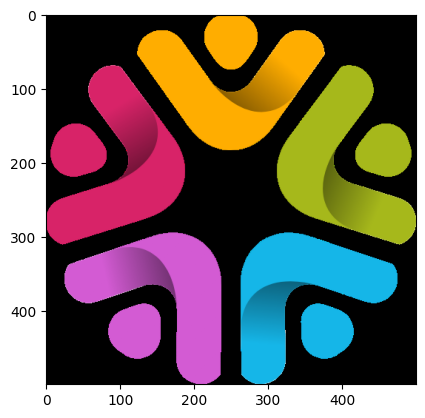

In [3]:
import matplotlib.pyplot as plt

plt.imshow(torch.permute(data[0][:3], (1, 2, 0)))